
# Livrable 3 — Image Captioning (InceptionV3 + Bahdanau Attention)

**Auteur :** Zied  
**Objectif :** Construire un pipeline **Image → Texte** complet (Image Captioning) en s'appuyant sur un **encodeur CNN pré‑entraîné** (**InceptionV3**) et un **décodeur RNN avec attention de Bahdanau**.

Le notebook est intégralement **commenté et expliqué**. Il suit les étapes :
1. **Imports & Configuration**
2. **Chargement des annotations COCO locales** et mapping images → légendes
3. **Prétraitement des images** (compatible InceptionV3) et constitution des `tf.data.Dataset` (sans *double batch*)
4. **Prétraitement du texte** : ajout `<start>/<end>` + **tokenizer** + **vectorisation** (padding)
5. **Modèle** : Encodeur **InceptionV3 (gelé)** + Décodeur **GRU + Attention Bahdanau**
6. **Perte masquée** + **préparation des datasets** pour `model.fit()`
7. **Entraînement**
8. **Inférence** : génération d'une légende sur une image de validation
9. **Sauvegarde** du modèle et du tokenizer

> **Structure attendue du dataset local :**
```
data/DatasetLiv3/archive/coco2014/
├── annotations/
│   ├── captions_train2014.json
│   └── captions_val2014.json
└── images/
    ├── train2014/
    └── val2014/
```



## 1) Imports & Configuration

- Fixe la graine aléatoire pour la reproductibilité.
- Active `memory_growth` pour éviter que TensorFlow alloue toute la VRAM au lancement.
- Définit les **hyperparamètres principaux** et **chemins** (dataset COCO local).


In [1]:

import os, json, random, pathlib
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

# Reproductibilité
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# GPU : éviter la pré-allocation agressive
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Warn(memory_growth):", e)

# Hyperparamètres généraux
AUTOTUNE   = tf.data.AUTOTUNE
BATCH_SIZE = 4
MAX_LEN    = 30          # longueur max des légendes (avec padding)
VOCAB_SIZE = 8000       # vocabulaire tronqué Top-K
OOV_TOKEN  = "<unk>"
START_TOKEN= "<start>"
END_TOKEN  = "<end>"

# Chemins dataset local (COCO 2014)
DATA_ROOT     = pathlib.Path("data/DatasetLiv3/archive/coco2014")
ANNOT_TRAIN   = DATA_ROOT / "annotations/captions_train2014.json"
ANNOT_VAL     = DATA_ROOT / "annotations/captions_val2014.json"
IMG_TRAIN_DIR = DATA_ROOT / "images/train2014"
IMG_VAL_DIR   = DATA_ROOT / "images/val2014"

# InceptionV3 → images 299x299
image_size = (299, 299)
print("✅ image_size:", image_size)


2025-10-20 16:06:08.620143: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ image_size: (299, 299)


In [2]:
import tensorflow as tf
tf.keras.backend.clear_session()

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)



## 2) Chargement des annotations COCO & mapping `filename → [captions]`

- Charge les fichiers JSON `captions_train2014.json` et `captions_val2014.json`.
- Construit un dictionnaire `filename -> liste de légendes` (plusieurs légendes par image).


In [3]:

# Chargement des annotations
with open(ANNOT_TRAIN, "r") as f:
    train_data = json.load(f)
with open(ANNOT_VAL, "r") as f:
    val_data   = json.load(f)

# Mapping image_id -> file_name
id2file_train = {img["id"]: img["file_name"] for img in train_data["images"]}
id2file_val   = {img["id"]: img["file_name"] for img in val_data["images"]}

# filename -> [captions]
def build_caption_map(data, id2file):
    cap_map = {}
    for ann in data["annotations"]:
        fname = id2file[ann["image_id"]]
        cap_map.setdefault(fname, []).append(ann["caption"])
    return cap_map

train_caps = build_caption_map(train_data, id2file_train)
val_caps   = build_caption_map(val_data,   id2file_val)

print(f"📊 train images: {len(train_caps)} | val images: {len(val_caps)}")


📊 train images: 82783 | val images: 40504



## 3) Prétraitement des images & `tf.data.Dataset` (sans *double batch*)

- **Prétraitement** : on applique le `preprocess_input` d'**InceptionV3** (mise à l'échelle **[-1, 1]**).
- **Générateur** : pour chaque image, on lit le fichier, on le redimensionne en **299×299**, on le normalise et on renvoie **(image, caption)**.
- **Datasets** `ds_train`, `ds_val` : **aucun `batch()` ici** pour éviter le problème de *double batch*. On batchera plus tard, juste avant l'entraînement.


In [4]:
# ✅ Import du preprocess adapté au backbone InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preproc

# ---------------------------------------------------------------------
# 🧹 1) Fonction de chargement robuste d'une image + légende
# ---------------------------------------------------------------------
def load_image_and_caption(filename, captions, base_dir):
    """
    Charge une image depuis base_dir/filename, la redimensionne à image_size,
    l'encode via le preprocess InceptionV3, et renvoie (image_tensor, caption aléatoire).
    ⚠️ Si l'image est absente ou corrompue, retourne None.
    """
    path = os.path.join(base_dir, filename)
    if not os.path.exists(path):
        # 🔸 Fichier manquant → on ignore
        return None, None
    try:
        img = Image.open(path).convert("RGB").resize(image_size)
        img = np.array(img).astype(np.float32)
        img = inception_preproc(img)  # normalisation [-1, 1]
        cap = random.choice(captions)
        return img, cap
    except Exception as e:
        print(f"⚠️ Erreur lors du chargement de {path}: {e}")
        return None, None

# ---------------------------------------------------------------------
# 🔄 2) Générateurs Python pour le dataset TensorFlow
# ---------------------------------------------------------------------
def gen_split(caps_map, base_dir):
    """
    Générateur Python : parcourt le dictionnaire {filename: [captions]} 
    et renvoie des paires (image prétraitée, caption).
    """
    for fname, caps in caps_map.items():
        img, cap = load_image_and_caption(fname, caps, base_dir)
        if img is not None and cap is not None:
            yield img, cap

# ---------------------------------------------------------------------
# ⚡ 3) Création des datasets TensorFlow (train / val)
# ---------------------------------------------------------------------
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42

# Dataset d'entraînement
ds_train = tf.data.Dataset.from_generator(
    lambda: gen_split(train_caps, IMG_TRAIN_DIR),
    output_signature=(
        tf.TensorSpec(shape=image_size + (3,), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.string)
    )
).shuffle(2048, seed=SEED).prefetch(AUTOTUNE)

# Dataset de validation
ds_val = tf.data.Dataset.from_generator(
    lambda: gen_split(val_caps, IMG_VAL_DIR),
    output_signature=(
        tf.TensorSpec(shape=image_size + (3,), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.string)
    )
).prefetch(AUTOTUNE)

# ---------------------------------------------------------------------
# 🔍 4) Vérification rapide
# ---------------------------------------------------------------------
try:
    sample_img, sample_cap = next(iter(ds_train.as_numpy_iterator()))
    print("🖼️ Exemple d'image :", sample_img.shape)
    print("📝 Exemple de légende :", sample_cap.decode("utf-8")[:90], "...")
except Exception as e:
    print("⚠️ Erreur pendant l'échantillonnage :", e)


I0000 00:00:1760976372.290327     169 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1765 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
2025-10-20 16:06:23.377103: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 862 of 2048


🖼️ Exemple d'image : (299, 299, 3)
📝 Exemple de légende : A plate that has several doughnuts and doughnut holes on it. ...


2025-10-20 16:06:40.917424: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.



## 4) Prétraitement du texte : `<start>/<end>` + Tokenizer + Vectorisation

- On **ajoute des tokens spéciaux** `<start>` et `<end>` aux légendes.
- On **construit un `Tokenizer` Keras** sur **toutes les légendes d'entraînement** (plus rapide et plus simple que d'itérer `tf.data`).
- On transforme chaque légende en **séquence d'indices** de taille fixe `MAX_LEN` via **padding**.
- Le pipeline garde **les strings** le plus longtemps possible, puis **vectorise** juste avant le batching.


In [5]:

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Construire la liste de captions train (texte brut) puis y ajouter <start>/<end>
captions_list = [f"{START_TOKEN} {c} {END_TOKEN}" for caps in train_caps.values() for c in caps]

# Tokenizer tronqué à VOCAB_SIZE
tok = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN,
                filters='!"#$%&()*+.,-/:;=?@[\\]^_`{|}~\t\n')
tok.fit_on_texts(captions_list)

VOCAB_ACTUAL = min(VOCAB_SIZE, len(tok.word_index) + 1)
print("✅ VOCAB_ACTUAL:", VOCAB_ACTUAL)

def add_tokens_tf(cap: tf.Tensor) -> tf.Tensor:
    '''Ajoute <start> et <end> en TensorFlow.'''
    return tf.strings.join([START_TOKEN, cap, END_TOKEN], separator=" ")

def vectorize_caption_tf(cap_str: tf.Tensor) -> tf.Tensor:
    '''Vectorise une légende texte -> séquence d'ids de longueur MAX_LEN.
       Utilise py_function pour rester robuste aux types (bytes/ndarray/str).'''
    def _py(s):
        s = s.numpy()
        if isinstance(s, bytes):
            txt = s.decode("utf-8")
        else:
            txt = str(s)
        seq = tok.texts_to_sequences([txt])[0]
        seq = pad_sequences([seq], maxlen=MAX_LEN, padding='post')[0]
        return seq.astype(np.int32)
    seq = tf.py_function(_py, inp=[cap_str], Tout=tf.int32)
    seq.set_shape((MAX_LEN,))
    return seq

# Datasets avec tokens ajoutés puis vectorisés (toujours sans batch ici)
ds_train_txt = ds_train.map(lambda im, cap: (im, add_tokens_tf(cap)), num_parallel_calls=AUTOTUNE)
ds_val_txt   = ds_val  .map(lambda im, cap: (im, add_tokens_tf(cap)), num_parallel_calls=AUTOTUNE)

ds_train_vec = ds_train_txt.map(lambda im, cap: (im, vectorize_caption_tf(cap)), num_parallel_calls=AUTOTUNE)
ds_val_vec   = ds_val_txt  .map(lambda im, cap: (im, vectorize_caption_tf(cap)), num_parallel_calls=AUTOTUNE)


✅ VOCAB_ACTUAL: 8000



## 5) Modèle : **InceptionV3 (gelé) + RNN (GRU) + Attention Bahdanau**

- **Encodeur CNN** : InceptionV3 pré‑entraîné ImageNet (`include_top=False`, `pooling='avg'`), gelé.
- **Attention Bahdanau** : calcule un contexte (ici global car features compactes).
- **Décodeur** : Embedding → Concat(Contexte, Embedding) → GRU → Dense → Logits vocab.  
  Version **vectorisée** (pas de boucle Python) pour être **compatible graphe Keras** et `model.fit()`.


In [6]:

from tensorflow.keras.applications import InceptionV3

# ----- Encodeur CNN
base_cnn = InceptionV3(include_top=False, weights='imagenet',
                       pooling='avg', input_shape=image_size+(3,))
base_cnn.trainable = False

encoder = tf.keras.Sequential([
    base_cnn,
    tf.keras.layers.Dense(512, activation='relu')
], name="cnn_encoder")

# ----- Attention Bahdanau
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V  = tf.keras.layers.Dense(1)
    def call(self, features, hidden):
        hidden_time = tf.expand_dims(hidden, 1)               # (B,1,U)
        score   = tf.nn.tanh(self.W1(features) + self.W2(hidden_time))
        weights = tf.nn.softmax(self.V(score), axis=1)        # (B,1,1) ici
        context = weights * tf.expand_dims(features, 1)       # (B,1,512)
        context = tf.reduce_sum(context, axis=1)              # (B,512)
        return context, weights

EMBED_DIM = 256
RNN_UNITS = 1024

# ----- Décodeur vectorisé
class RNNDecoder(tf.keras.Model):
    def __init__(self, units, vocab_size, emb_dim):
        super().__init__()
        self.units = units
        self.attn = BahdanauAttention(units)
        self.embedding = tf.keras.layers.Embedding(vocab_size, emb_dim, mask_zero=True)
        self.gru = tf.keras.layers.GRU(units, return_sequences=True, return_state=True)
        self.fc1 = tf.keras.layers.Dense(units, activation='relu')
        self.fc2 = tf.keras.layers.Dense(vocab_size)
    def call(self, features, seq_inputs):
        # features: (B,512) ; seq_inputs: (B,MAX_LEN)
        hidden = tf.zeros((tf.shape(seq_inputs)[0], self.units))
        context, _ = self.attn(features, hidden)   # (B,512)
        context = tf.expand_dims(context, 1)       # (B,1,512)
        context = tf.tile(context, [1, tf.shape(seq_inputs)[1], 1])  # (B,MAX_LEN,512)
        x = self.embedding(seq_inputs)             # (B,MAX_LEN,EMB)
        x = tf.concat([context, x], axis=-1)       # (B,MAX_LEN,512+EMB)
        out, _ = self.gru(x)                       # (B,MAX_LEN,U)
        x = self.fc1(out)                          # (B,MAX_LEN,U)
        logits = self.fc2(x)                       # (B,MAX_LEN,V)
        return logits

decoder = RNNDecoder(RNN_UNITS, VOCAB_ACTUAL, EMBED_DIM)

# ----- Modèle complet
img_in = tf.keras.Input(shape=image_size+(3,), name="image")
seq_in = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name="seq")

features = encoder(img_in)               # (B,512)
logits   = decoder(features, seq_in)     # (B,MAX_LEN,VOCAB_ACTUAL)

model = tf.keras.Model([img_in, seq_in], logits, name="caption_model")
model.summary()


Model: "caption_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 299, 299,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_encoder         │ (None, 512)       │ 22,851,872 │ image[0][0]       │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq (InputLayer)    │ (None, 30)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rnn_decoder         │ (None, 30, 8000)  │ 18,384,705 │ cnn_encoder[0][0… │
│ (RNNDecoder)        │                   │            │ seq[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,236,577 (157.31 MB)

 Trainable params: 19,433,793 (74.13 MB)

 Non-trainable params: 21,802,784 (83.17 MB)


## 6) Perte masquée & préparation des datasets pour l'entraînement

- On **batch** les datasets **à ce stade uniquement** (évite le *double batch*).
- On fabrique `(inputs, targets)` où la **cible** est la séquence **décalée d’un token**.
- La **perte masquée** ignore les `0` (padding).


In [7]:

# Batch ici (une seule fois)
train_batched = ds_train_vec.batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_batched   = ds_val_vec.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Inputs / targets (décalage)
def split_inputs_targets(img, seq):
    seq_out = tf.concat([seq[:, 1:], tf.zeros_like(seq[:, :1])], axis=1)[:, :MAX_LEN]
    return (img, seq), seq_out

# ⚠️ on map directement sur les datasets déjà batchés
train_proc = train_batched.map(split_inputs_targets, num_parallel_calls=AUTOTUNE)
val_proc   = val_batched.map(split_inputs_targets, num_parallel_calls=AUTOTUNE)

# ⚠️ on n'oublie pas de pré-batcher avant le mapping

# Perte masquée
loss_obj = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')
def masked_loss(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    loss = loss_obj(y_true, y_pred) * mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

optimizer = tf.keras.optimizers.Adam(1e-3)
model.compile(optimizer=optimizer, loss=masked_loss)

# Vérif des formes
for (imgs, seq_inp), seq_out in train_proc.take(1):
    print("🧪 imgs:", imgs.shape, "| seq_in:", seq_inp.shape, "| seq_out:", seq_out.shape)


2025-10-20 16:06:59.212322: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 750 of 2048
2025-10-20 16:07:09.209412: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1671 of 2048


🧪 imgs: (4, 299, 299, 3) | seq_in: (4, 30) | seq_out: (4, 30)


2025-10-20 16:07:13.279487: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2025-10-20 16:07:13.344147: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



## 7) Entraînement

- On commence par un **test rapide** avec `.take(N)` pour valider que tout s'exécute.
- Retirez `.take(...)` pour un **entraînement complet**.


In [8]:
import tensorflow as tf

# ✅ Active la croissance dynamique de la mémoire GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU activé : {gpus}")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ Aucun GPU détecté, exécution sur CPU.")


    


✅ GPU activé : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
BATCH_SIZE = 2
EPOCHS = 10

history = model.fit(
    train_proc,
    validation_data=val_proc,
    epochs=EPOCHS
)


Epoch 1/10


2025-10-20 16:07:29.034743: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 796 of 2048
2025-10-20 16:07:44.693974: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2025-10-20 16:07:44.789257: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90800
2025-10-20 16:07:45.740464: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:382] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.
2025-10-20 16:07:45.903993: W external/local_xla/xla

  20695/Unknown 1381s 65ms/step - loss: 3.8959

2025-10-20 16:30:14.320551: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.97GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


  20696/Unknown 1382s 65ms/step - loss: 3.8959

...

2025-10-20 20:54:57.565263: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 8727115354598176855
2025-10-20 20:54:57.565342: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 25014324405918337
2025-10-20 20:54:57.565352: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 4486612953581064117
2025-10-20 20:55:07.631528: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 688 of 2048
2025-10-20 20:55:17.624022: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1382 of 2048
2025-10-20 20:55:29.543223: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


20696/20696 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 3.3294

2025-10-20 21:18:19.639931: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 17052519814884108668
2025-10-20 21:18:19.639966: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 1248313840952005579
2025-10-20 21:18:19.639971: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 10976117623466085693


20696/20696 ━━━━━━━━━━━━━━━━━━━━ 1963s 93ms/step - loss: 3.2311 - val_loss: 3.6769


2025-10-20 21:27:40.894808: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 8727115354598176855
2025-10-20 21:27:40.894860: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 25014324405918337
2025-10-20 21:27:40.894865: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 4486612953581064117


## Visualiser les pertes


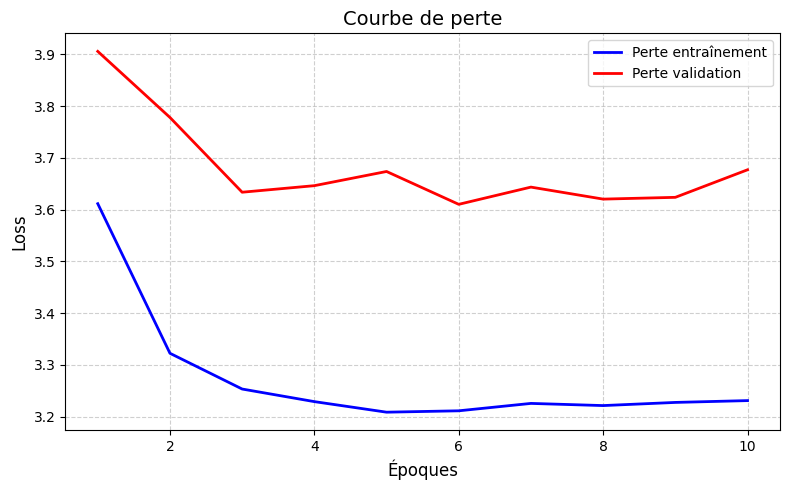

In [10]:
import matplotlib.pyplot as plt

# Récupération des pertes
train_loss = history.history.get('loss', [])
val_loss = history.history.get('val_loss', [])
epochs = range(1, len(train_loss) + 1)

# Courbe de perte
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, 'b-', label='Perte entraînement', linewidth=2)
if val_loss:
    plt.plot(epochs, val_loss, 'r-', label='Perte validation', linewidth=2)

plt.title("Courbe de perte", fontsize=14)
plt.xlabel("Époques", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()



## 8) Inférence (génération de légende, stratégie **greedy**)

- On encode l'image via l'encodeur.
- On génère **token par token** en prenant à chaque pas l'**argmax** des logits (greedy).
- On s'arrête si on rencontre `<end>` ou si on atteint `MAX_LEN`.


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


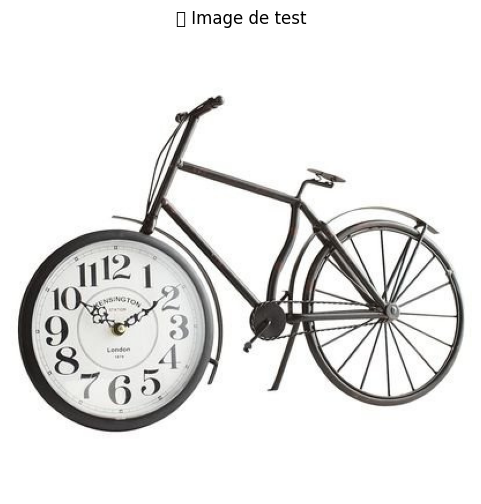

📂 Test image: data/DatasetLiv3/archive/coco2014/images/val2014/COCO_val2014_000000203564.jpg
➡️ Encodage de l'image...


2025-10-20 21:27:44.307050: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ff91c5a51a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-20 21:27:44.307120: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-10-20 21:27:44.437931: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-20 21:27:46.877348: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.93GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
I0000 00:00:1760995673.242638     245 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of 

➡️ Début de génération avec token <start>
✅ Légende générée (11 tokens) : a clock on a wall with a clock on it
🧾 Caption prédite: a clock on a wall with a clock on it


In [11]:
from tensorflow.keras.preprocessing.sequence import pad_sequences as _pad

index2word = {i:w for w,i in tok.word_index.items() if i < VOCAB_ACTUAL}
index2word[tok.word_index.get(OOV_TOKEN, 1)] = OOV_TOKEN
index2word[0] = ""  # pad

def preprocess_image_path(path):
    img = Image.open(path).convert("RGB").resize(image_size)
    x = np.array(img).astype(np.float32)
    x = inception_preproc(x)
    return x

def generate_caption(img_path, max_len=MAX_LEN, verbose=True):
    # 1️⃣ Prétraitement et encodage
    x = preprocess_image_path(img_path)
    x = np.expand_dims(x, 0)
    if verbose:
        print("➡️ Encodage de l'image...")
    feat = encoder.predict(x, verbose=0)   # (1,512)

    # 2️⃣ Boucle de génération (greedy)
    start_id = tok.word_index.get(START_TOKEN, None)
    end_id   = tok.word_index.get(END_TOKEN, None)
    assert start_id is not None and end_id is not None

    seq = [start_id]
    if verbose:
        print("➡️ Début de génération avec token <start>")

    for t in range(max_len-1):
        seq_padded = _pad([seq], maxlen=MAX_LEN, padding='post')
        logits = decoder(feat, tf.constant(seq_padded, dtype=tf.int32))
        next_id = int(tf.argmax(logits[:, t, :], axis=-1).numpy()[0])
        if next_id == end_id or next_id == 0:
            break
        seq.append(next_id)

    words = [index2word.get(i, OOV_TOKEN) for i in seq if i not in (start_id, end_id, 0)]
    caption = " ".join(words)
    if verbose:
        print(f"✅ Légende générée ({len(seq)} tokens) : {caption}")
    return caption


# 🔍 Test sur une image de validation + affichage
any_val_file = next(iter(val_caps.keys()))
test_path = os.path.join(IMG_VAL_DIR, any_val_file)

# Afficher l'image
plt.figure(figsize=(6, 6))
img_disp = Image.open(test_path)
plt.imshow(img_disp)
plt.axis("off")
plt.title("🖼️ Image de test")
plt.show()

# Génération
print("📂 Test image:", test_path)
pred_caption = generate_caption(test_path)
print("🧾 Caption prédite:", pred_caption)


/tmp/ipykernel_169/2423290334.py:39: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


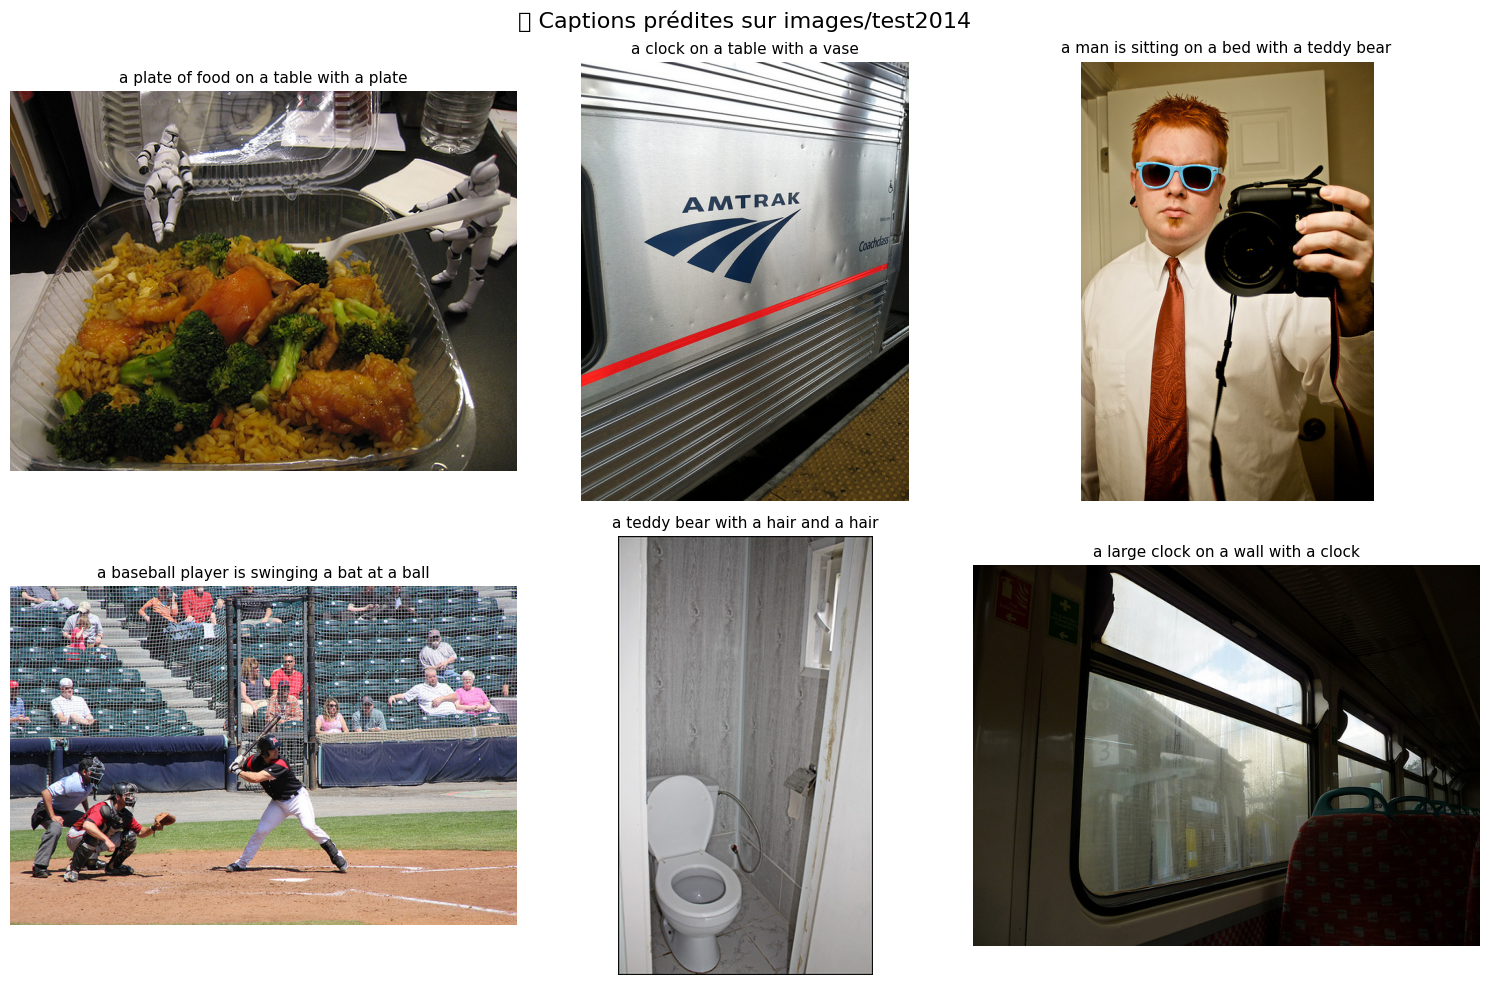

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
import random

# 📁 Dossier contenant les images de test
TEST_IMG_DIR = "data/DatasetLiv3/archive/coco2014/images/test2014"  # <-- adapte ce chemin si besoin

# Liste de toutes les images disponibles
all_test_images = [os.path.join(TEST_IMG_DIR, f) 
                   for f in os.listdir(TEST_IMG_DIR) 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# 🔢 Nombre d’images à afficher
num_images = 6
sample_files = random.sample(all_test_images, min(num_images, len(all_test_images)))

# 📊 Configuration de la grille
cols = 3
rows = int(np.ceil(len(sample_files) / cols))
plt.figure(figsize=(15, 5 * rows))

# 🧠 Boucle sur les images sélectionnées
for i, img_path in enumerate(sample_files):
    # Génération du caption prédite
    caption = generate_caption(img_path, verbose=False)
    
    # Lecture de l’image
    img_disp = Image.open(img_path)
    
    # Affichage
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img_disp)
    plt.axis("off")
    plt.title(caption, fontsize=11, wrap=True)

plt.suptitle("🖼️ Captions prédites sur images/test2014", fontsize=16)
plt.tight_layout()
plt.show()



## 9) Sauvegarde du modèle et du tokenizer

- Sauvegarde le **modèle Keras** (`.h5`) et le **tokenizer** (pickle).


In [13]:
# 📦 Sauvegarde du modèle et du tokenizer
MODEL_DIR = "outputs/checkpoints_inceptionv3_caption"
os.makedirs(MODEL_DIR, exist_ok=True)

# Sauvegarde du modèle Keras
model.save(os.path.join(MODEL_DIR, "caption_model.h5"))

# Sauvegarde du tokenizer
import pickle
with open(os.path.join(MODEL_DIR, "tokenizer.pkl"), "wb") as f:
    pickle.dump(tok, f)

print(f"✅ Modèle et tokenizer sauvegardés dans : {MODEL_DIR}")


✅ Modèle et tokenizer sauvegardés dans : outputs/checkpoints_inceptionv3_caption
